# Plasma Shape Prediction with CNN

This notebook demonstrates:
1. Fetching DIII-D plasma shape data (kappa and psirz)
2. Training a small CNN to predict kappa from psirz
3. Evaluating the model on test data

**Note**: Data fetching uses `fdp python` which requires the FDP environment. The notebook uses subprocess to run the data fetching script.

## Install Dependencies

In [5]:
! pip install -q torch torchvision xarray netCDF4 matplotlib numpy scipy

## Import Libraries

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import subprocess
import os
import time

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.10.0+cpu
CUDA available: False


## Part 1: Fetch Plasma Shape Data

This cell creates and runs a data fetching script using `fdp python` to access DIII-D data through Pelican.

In [7]:
# Create the data fetching script
fetch_script = '''
from toksearch import MdsSignal, Pipeline
import numpy as np
import xarray as xr
from scipy.ndimage import zoom

def create_pipeline(shots):
    pipe = Pipeline(shots)
    dims = ("r", "z", "times")
    kappa_signal = MdsSignal(r"\\kappa", "efit01")
    psirz_signal = MdsSignal(r"\\psirz", "efit01", dims=dims, data_order=["times", "z", "r"])
    pipe.fetch_dataset("ds", {"kappa": kappa_signal, "psirz": psirz_signal})

    @pipe.where
    def no_errors(rec):
        return not rec.errors

    return pipe

def resize_psirz(psirz, target_size=65):
    """Resize psirz array to target_size x target_size using interpolation."""
    if psirz.shape[1] == target_size and psirz.shape[2] == target_size:
        return psirz
    
    # Calculate zoom factors
    zoom_factors = (1, target_size / psirz.shape[1], target_size / psirz.shape[2])
    resized = zoom(psirz, zoom_factors, order=1)
    return resized


def main():
    first_shot = 160000
    last_shot = 195000
    target_shots = 2200
    
    print(f"Fetching {target_shots} valid shots between {first_shot} and {last_shot}")
    print()
    
    valid_shots = []
    attempt = 1
    
    while len(valid_shots) < target_shots:
        batch_size = min(500, target_shots - len(valid_shots))
        shots = np.random.randint(first_shot, last_shot + 1, batch_size)
        
        print(f"Attempt {attempt}: Processing {batch_size} shots (have {len(valid_shots)} valid so far)")
        
        pipe = create_pipeline(shots)
        results = pipe.compute_multiprocessing()
        
        new_valid = [res for res in results if not res['errors']]
        print(f"Got {len(new_valid)} valid shots from this batch")
        print()
        
        valid_shots.extend(new_valid)
        attempt += 1
    
    # Trim to exactly target_shots
    valid_shots = valid_shots[:target_shots]
    print(f"Successfully found {len(valid_shots)} valid shots")
    print()
    
    # Split into train/test (70/30)
    np.random.shuffle(valid_shots)
    split_idx = int(0.7 * len(valid_shots))
    train_shots = valid_shots[:split_idx]
    test_shots = valid_shots[split_idx:]
    
    print(f"Split: {len(train_shots)} training shots, {len(test_shots)} test shots")
    print()
    
    # Combine training data
    print("Combining training data...")
    train_kappa_list = []
    train_psirz_list = []
    train_time_offsets = [0]
    
    for res in train_shots:
        ds = res['ds']
        kappa = ds['kappa'].values
        psirz = ds['psirz'].values
        train_kappa_list.append(kappa)
        train_psirz_list.append(resize_psirz(psirz))
        train_time_offsets.append(train_time_offsets[-1] + len(kappa))
    
    train_kappa = np.concatenate(train_kappa_list)
    train_psirz = np.concatenate(train_psirz_list, axis=0)
    
    print(f"Training dataset shape: kappa={train_kappa.shape}, psirz={train_psirz.shape}")
    print()
    
    # Combine test data
    print("Combining test data...")
    test_kappa_list = []
    test_psirz_list = []
    
    for res in test_shots:
        ds = res['ds']
        kappa = ds['kappa'].values
        psirz = ds['psirz'].values
        test_kappa_list.append(kappa)
        test_psirz_list.append(resize_psirz(psirz))
    
    test_kappa = np.concatenate(test_kappa_list)
    test_psirz = np.concatenate(test_psirz_list, axis=0)
    
    print(f"Test dataset shape: kappa={test_kappa.shape}, psirz={test_psirz.shape}")
    print()
    
    # Create continuous time axis
    train_times = np.arange(len(train_kappa))
    test_times = np.arange(len(test_kappa))
    
    # Save as netCDF
    train_ds = xr.Dataset(
        {
            'kappa': (['times'], train_kappa),
            'psirz': (['times', 'z', 'r'], train_psirz)
        },
        coords={'times': train_times}
    )
    
    test_ds = xr.Dataset(
        {
            'kappa': (['times'], test_kappa),
            'psirz': (['times', 'z', 'r'], test_psirz)
        },
        coords={'times': test_times}
    )
    
    train_path = 'plasma_shape_train.nc'
    test_path = 'plasma_shape_test.nc'
    
    print(f"Saving training data to {train_path}")
    train_ds.to_netcdf(train_path)
    
    print(f"Saving test data to {test_path}")
    test_ds.to_netcdf(test_path)
    
    print()
    print("Done!")
    print(f"Training data: {len(train_shots)} shots, {len(train_kappa)} time points")
    print(f"Test data: {len(test_shots)} shots, {len(test_kappa)} time points")

if __name__ == "__main__":
    main()
'''

# Write the fetch script
fetch_script_path = 'fetch_plasma_shape_notebook.py'
with open(fetch_script_path, 'w') as f:
    f.write(fetch_script)

print("Data fetching script created.")
print("\nRunning data fetching with fdp python...")
print("This may take several minutes...")

Data fetching script created.

Running data fetching with fdp python...
This may take several minutes...


In [8]:
# Run the data fetching script using fdp python
# This uses subprocess to execute the script in the FDP environment
start_time = time.time()

try:
    result = subprocess.run(
        ['fdp', 'python', fetch_script_path],
        capture_output=True,
        text=True,
        timeout=600  # 10 minute timeout
    )
    
    # Print output
    print(result.stdout)
    if result.stderr:
        print("STDERR:", result.stderr)
    
    if result.returncode != 0:
        print(f"\nError: Data fetching failed with return code {result.returncode}")
    else:
        elapsed = time.time() - start_time
        print(f"\nData fetching completed in {elapsed:.1f} seconds")
        
except subprocess.TimeoutExpired:
    print("\nError: Data fetching timed out after 10 minutes")
except FileNotFoundError:
    print("\nError: 'fdp' command not found.")
    print("Please ensure you're in the FDP environment or install the required dependencies.")
except Exception as e:
    print(f"\nError: {str(e)}")

Fetching 2200 valid shots between 160000 and 195000

Attempt 1: Processing 500 shots (have 0 valid so far)
Got 311 valid shots from this batch

Attempt 2: Processing 500 shots (have 311 valid so far)
Got 294 valid shots from this batch

Attempt 3: Processing 500 shots (have 605 valid so far)
Got 296 valid shots from this batch

Attempt 4: Processing 500 shots (have 901 valid so far)
Got 317 valid shots from this batch

Attempt 5: Processing 500 shots (have 1218 valid so far)
Got 313 valid shots from this batch

Attempt 6: Processing 500 shots (have 1531 valid so far)
Got 323 valid shots from this batch

Attempt 7: Processing 346 shots (have 1854 valid so far)
Got 213 valid shots from this batch

Attempt 8: Processing 133 shots (have 2067 valid so far)
Got 80 valid shots from this batch

Attempt 9: Processing 53 shots (have 2147 valid so far)
Got 32 valid shots from this batch

Attempt 10: Processing 21 shots (have 2179 valid so far)
Got 15 valid shots from this batch

Attempt 11: Proce

## Part 2: Define CNN Model Architecture

In [9]:
class SmallCNN(nn.Module):
    """Small CNN for predicting kappa from psirz."""
    
    def __init__(self, input_channels=1, output_dim=1):
        super(SmallCNN, self).__init__()
        # Conv block 1: reduces spatial dimensions
        self.conv1 = nn.Conv2d(input_channels, 5, kernel_size=5,
                               stride=2, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=3, stride=2)

        # Conv block 2: further reduction
        self.conv2 = nn.Conv2d(5, 15, kernel_size=5, stride=2)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=1)

        # Fully connected layers with dropout
        self.fc1 = nn.Linear(375, 100)
        self.relu3 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.2)

        self.fc2 = nn.Linear(100, 30)
        self.relu4 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2)

        self.fc3 = nn.Linear(30, output_dim)

    def forward(self, x):
        # Input: (batch, 1, 65, 65) -> Output: (batch, 5, 31, 31)
        x = self.pool1(self.relu1(self.conv1(x)))
        # Output: (batch, 15, 6, 6)
        x = self.pool2(self.relu2(self.conv2(x)))
        # Flatten
        x = torch.flatten(x, 1)
        # FC layers
        x = self.dropout1(self.relu3(self.fc1(x)))
        x = self.dropout2(self.relu4(self.fc2(x)))
        x = self.fc3(x)
        return x

print("CNN model class defined.")

CNN model class defined.


## Part 3: Data Loading and Preprocessing

In [10]:
def normalize_to_range(tensor):
    """
    Normalize each 2D array to range [0, 1] using its own min/max.

    Args:
        tensor: Shape (N, H, W) where N is number of samples

    Returns:
        Normalized tensor with same shape, values in [0, 1]
    """
    normalized_list = []
    for i in range(tensor.size(0)):
        array_2d = tensor[i]
        max_val = array_2d.max()
        min_val = array_2d.min()
        range_val = max_val - min_val
        # Avoid division by zero
        if range_val > 0:
            normalized_array = (array_2d - min_val) / range_val
        else:
            normalized_array = torch.zeros_like(array_2d)
        normalized_list.append(normalized_array)

    return torch.stack(normalized_list)

# Load training data
print("Loading training data...")
train_ds = xr.open_dataset('plasma_shape_train.nc')

# Extract data
x_train = train_ds['psirz'].values  # Shape: (N, 65, 65)
y_train = train_ds['kappa'].values  # Shape: (N,)

print(f"Training data shape: psirz={x_train.shape}, kappa={y_train.shape}")

# Convert to tensors
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

# Normalize psirz per-sample to [0, 1]
print("Normalizing psirz per-sample to [0, 1]...")
x_train_normalized = normalize_to_range(x_train_tensor)

# Normalize kappa using z-score
print("Normalizing kappa using z-score...")
y_mean = y_train_tensor.mean().item()
y_std = y_train_tensor.std().item()
y_train_normalized = (y_train_tensor - y_mean) / y_std

print(f"Kappa statistics: mean={y_mean:.4f}, std={y_std:.4f}")

# Add channel dimension for Conv2d: (N, H, W) -> (N, 1, H, W)
x_train_normalized = torch.unsqueeze(x_train_normalized, 1)

# Create TensorDataset
dataset = TensorDataset(x_train_normalized, y_train_normalized)

# Split into train/validation (80/20)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size],
                                           generator=torch.Generator().manual_seed(42))

print(f"Train/val split: {train_size} training samples, {val_size} validation samples")

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

print("Data loading complete!")

Loading training data...
Training data shape: psirz=(331181, 65, 65), kappa=(331181,)
Normalizing psirz per-sample to [0, 1]...
Normalizing kappa using z-score...
Kappa statistics: mean=1.7425, std=0.1603
Train/val split: 264944 training samples, 66237 validation samples
Data loading complete!


In [11]:
# Use the data already loaded in the previous cell
train_psirz = x_train  # Shape: (N, 65, 65)
train_kappa = y_train  # Shape: (N,)

print(f"Training data shape: psirz={train_psirz.shape}, kappa={train_kappa.shape}")
print(f"Data type: psirz={train_psirz.dtype}, kappa={train_kappa.dtype}")
print(f"Memory usage: psirz={train_psirz.nbytes / 1e9:.2f} GB, kappa={train_kappa.nbytes / 1e6:.2f} MB")

Training data shape: psirz=(331181, 65, 65), kappa=(331181,)
Data type: psirz=float32, kappa=float32
Memory usage: psirz=5.60 GB, kappa=1.32 MB


## Exploratory Data Visualization

Let's explore the data to understand the plasma flux surfaces and kappa distribution.

Sample psirz shape: (65, 65)
Sample kappa value: 1.7080


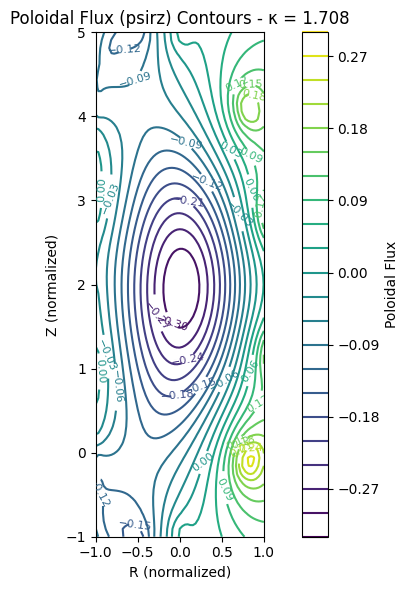

Contour plot saved to psirz_contour_sample.png


In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Load a sample psirz and kappa for visualization
sample_idx = 10000  # Pick a random time point
sample_psirz = train_psirz[sample_idx]  # Shape: (65, 65)
sample_kappa = train_kappa[sample_idx]

print(f"Sample psirz shape: {sample_psirz.shape}")
print(f"Sample kappa value: {sample_kappa:.4f}")

# Create coordinate grids
r = np.linspace(-1, 1, 65)
z = np.linspace(-1, 5, 65)
R, Z = np.meshgrid(r, z)

# Create contour plot
fig, ax = plt.subplots(figsize=(8, 6))
contour = ax.contour(R, Z, sample_psirz, levels=20, cmap='viridis')
ax.clabel(contour, inline=True, fontsize=8)
ax.set_xlabel('R (normalized)')
ax.set_ylabel('Z (normalized)')
ax.set_title(f'Poloidal Flux (psirz) Contours - κ = {sample_kappa:.3f}')
ax.set_aspect('equal')
plt.colorbar(contour, label='Poloidal Flux')
plt.tight_layout()
plt.savefig('psirz_contour_sample.png', dpi=150, bbox_inches='tight')
plt.show()

print("Contour plot saved to psirz_contour_sample.png")

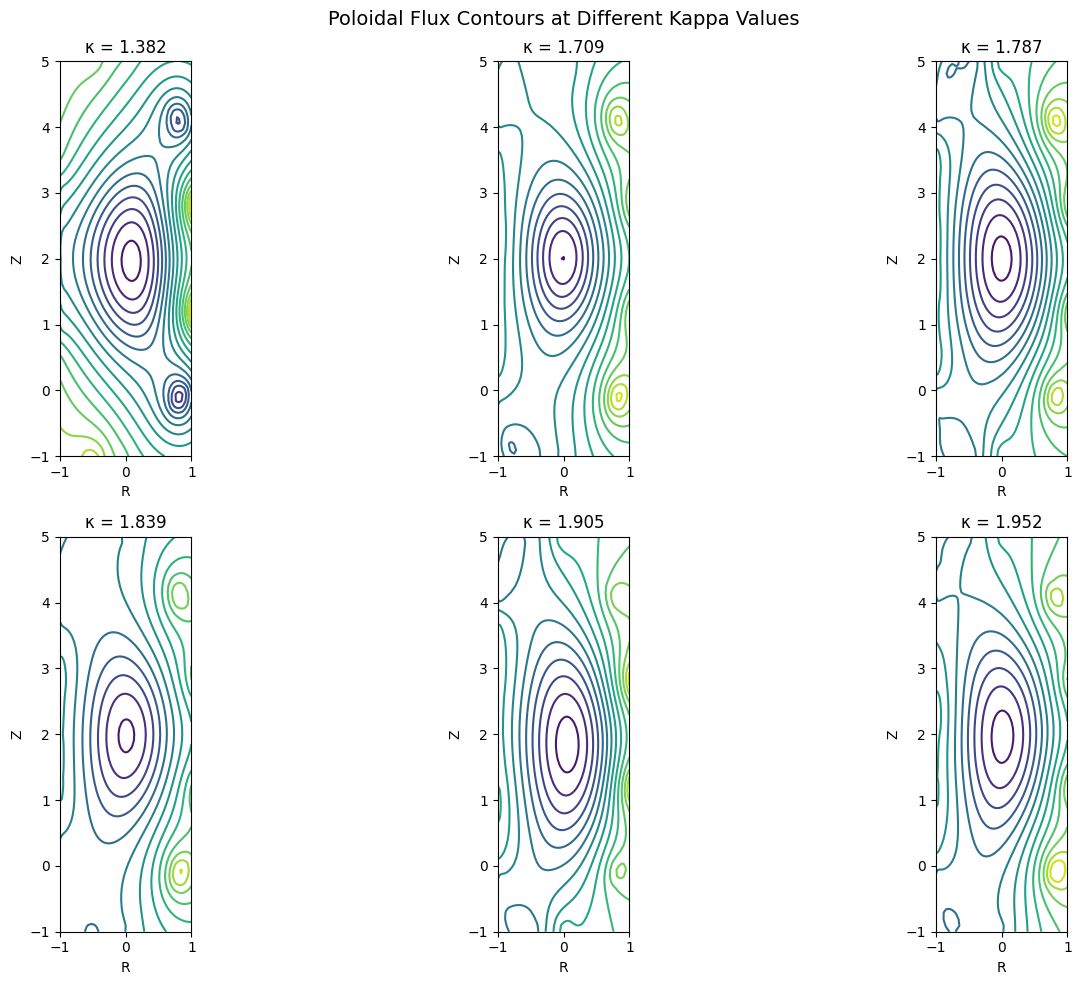

Multiple contour plots saved to psirz_contours_multiple.png


In [13]:
# Create multiple contour plots with different kappa values
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Select samples with different kappa values
kappa_percentiles = [5, 25, 50, 75, 95, 99]
selected_indices = []
for p in kappa_percentiles:
    idx = np.argmin(np.abs(train_kappa - np.percentile(train_kappa, p)))
    selected_indices.append(idx)

for i, (ax, idx) in enumerate(zip(axes, selected_indices)):
    psirz = train_psirz[idx]
    kappa = train_kappa[idx]
    
    contour = ax.contour(R, Z, psirz, levels=15, cmap='viridis')
    ax.set_xlabel('R')
    ax.set_ylabel('Z')
    ax.set_title(f'κ = {kappa:.3f}')
    ax.set_aspect('equal')

plt.suptitle('Poloidal Flux Contours at Different Kappa Values', fontsize=14)
plt.tight_layout()
plt.savefig('psirz_contours_multiple.png', dpi=150, bbox_inches='tight')
plt.show()

print("Multiple contour plots saved to psirz_contours_multiple.png")

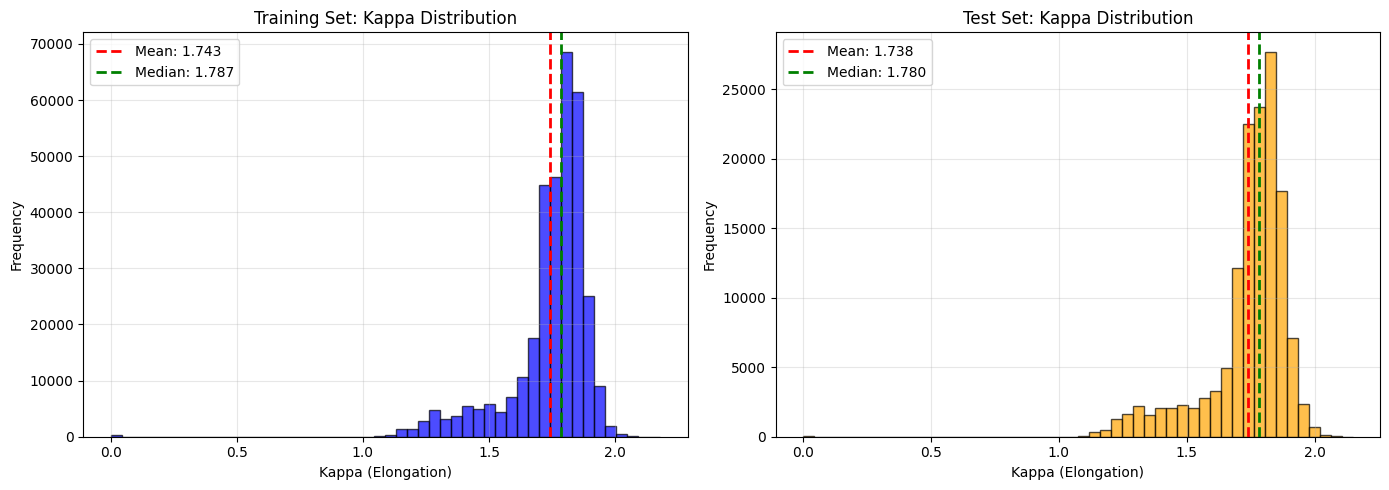

Training set: 331181 samples, mean=1.7425, std=0.1603
Test set: 141272 samples, mean=1.7383, std=0.1588
Histogram saved to kappa_histogram.png


In [14]:
# Load test data for histogram
test_ds = xr.open_dataset('plasma_shape_test.nc')
test_kappa = test_ds['kappa'].values

# Histogram of kappa values
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Training set histogram
ax1.hist(train_kappa, bins=50, alpha=0.7, color='blue', edgecolor='black')
ax1.axvline(train_kappa.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {train_kappa.mean():.3f}')
ax1.axvline(np.median(train_kappa), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(train_kappa):.3f}')
ax1.set_xlabel('Kappa (Elongation)')
ax1.set_ylabel('Frequency')
ax1.set_title('Training Set: Kappa Distribution')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Test set histogram
test_kappa = test_ds['kappa'].values
ax2.hist(test_kappa, bins=50, alpha=0.7, color='orange', edgecolor='black')
ax2.axvline(test_kappa.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {test_kappa.mean():.3f}')
ax2.axvline(np.median(test_kappa), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(test_kappa):.3f}')
ax2.set_xlabel('Kappa (Elongation)')
ax2.set_ylabel('Frequency')
ax2.set_title('Test Set: Kappa Distribution')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kappa_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Training set: {len(train_kappa)} samples, mean={train_kappa.mean():.4f}, std={train_kappa.std():.4f}")
print(f"Test set: {len(test_kappa)} samples, mean={test_kappa.mean():.4f}, std={test_kappa.std():.4f}")
print("Histogram saved to kappa_histogram.png")

In [15]:
# Statistical summary of kappa values
print("="*60)
print("KAPPA STATISTICAL SUMMARY")
print("="*60)

print("\nTraining Set:")
print(f"  Count: {len(train_kappa):,}")
print(f"  Mean: {train_kappa.mean():.4f}")
print(f"  Std:  {train_kappa.std():.4f}")
print(f"  Min:  {train_kappa.min():.4f}")
print(f"  25th percentile: {np.percentile(train_kappa, 25):.4f}")
print(f"  50th percentile (median): {np.percentile(train_kappa, 50):.4f}")
print(f"  75th percentile: {np.percentile(train_kappa, 75):.4f}")
print(f"  Max:  {train_kappa.max():.4f}")

print("\nTest Set:")
print(f"  Count: {len(test_kappa):,}")
print(f"  Mean: {test_kappa.mean():.4f}")
print(f"  Std:  {test_kappa.std():.4f}")
print(f"  Min:  {test_kappa.min():.4f}")
print(f"  25th percentile: {np.percentile(test_kappa, 25):.4f}")
print(f"  50th percentile (median): {np.percentile(test_kappa, 50):.4f}")
print(f"  75th percentile: {np.percentile(test_kappa, 75):.4f}")
print(f"  Max:  {test_kappa.max():.4f}")
print("="*60)

KAPPA STATISTICAL SUMMARY

Training Set:
  Count: 331,181
  Mean: 1.7425
  Std:  0.1603
  Min:  0.0000
  25th percentile: 1.7093
  50th percentile (median): 1.7869
  75th percentile: 1.8386
  Max:  2.1784

Test Set:
  Count: 141,272
  Mean: 1.7383
  Std:  0.1588
  Min:  0.0000
  25th percentile: 1.7096
  50th percentile (median): 1.7802
  75th percentile: 1.8354
  Max:  2.1478


## Part 4: Train the Model

In [16]:
def train_model(model, train_loader, val_loader, epochs, device, lr=0.001):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        epoch_start = time.time()

        # Training phase
        model.train()
        train_loss = 0.0
        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            # Forward pass
            predictions = model(x_batch)
            predictions = torch.squeeze(predictions, dim=1)  # Remove extra dim
            loss = loss_fn(predictions, y_batch)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)

                predictions = model(x_batch)
                predictions = torch.squeeze(predictions, dim=1)
                loss = loss_fn(predictions, y_batch)
                val_loss += loss.item()

        val_loss /= len(val_loader)

        epoch_time = time.time() - epoch_start

        print(f'Epoch {epoch+1}/{epochs} ({epoch_time:.1f}s) - '
              f'Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    return train_losses, val_losses

# Create model
print("Creating SmallCNN model...")
model = SmallCNN(input_channels=1, output_dim=1)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Train model
device = torch.device("cpu")  # CPU environment
print(f"\nTraining on {device} for 5 epochs...")
train_losses, val_losses = train_model(model, train_loader, val_loader,
                                       epochs=5, device=device, lr=0.001)

print("\nTraining complete!")
print(f"Final train loss: {train_losses[-1]:.4f}")
print(f"Final val loss: {val_losses[-1]:.4f}")

Creating SmallCNN model...
Total parameters: 42,681
Trainable parameters: 42,681

Training on cpu for 5 epochs...
Epoch 1/5 (38.6s) - Train Loss: 0.1523, Val Loss: 0.0648
Epoch 2/5 (39.5s) - Train Loss: 0.0792, Val Loss: 0.0372
Epoch 3/5 (36.0s) - Train Loss: 0.0672, Val Loss: 0.0398
Epoch 4/5 (32.2s) - Train Loss: 0.0621, Val Loss: 0.0331
Epoch 5/5 (34.7s) - Train Loss: 0.0564, Val Loss: 0.0290

Training complete!
Final train loss: 0.0564
Final val loss: 0.0290


## Part 5: Save Model and Plot Training Curves

Model weights saved to cnn_kappa_model.pth
Normalization parameters saved to normalization_params.npy


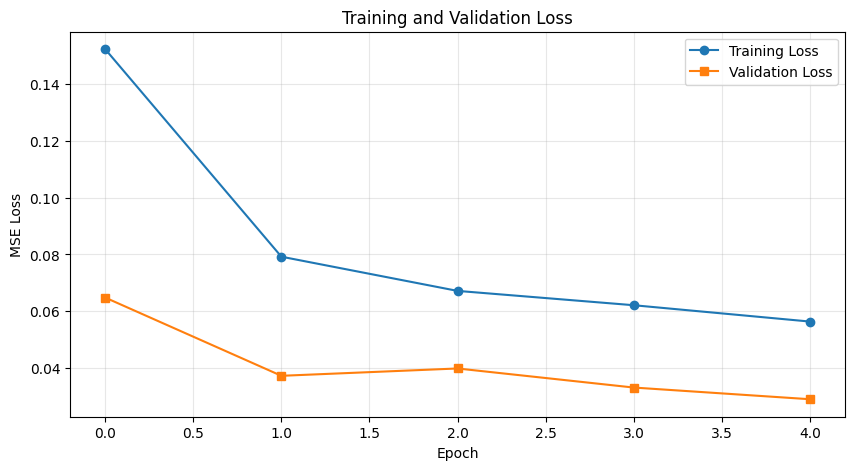

Loss curves saved to loss_curves.png


In [17]:
# Save model weights
model_path = 'cnn_kappa_model.pth'
torch.save(model.state_dict(), model_path)
print(f"Model weights saved to {model_path}")

# Save normalization parameters
norm_params = {'y_mean': y_mean, 'y_std': y_std}
np.save('normalization_params.npy', norm_params)
print("Normalization parameters saved to normalization_params.npy")

# Plot loss curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
loss_curve_path = 'loss_curves.png'
plt.savefig(loss_curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Loss curves saved to {loss_curve_path}")

## Part 6: Evaluate on Test Set

In [18]:
# Load test data
print("Loading test data...")
test_ds = xr.open_dataset('plasma_shape_test.nc')

# Extract data
x_test = test_ds['psirz'].values  # Shape: (N, 65, 65)
y_test = test_ds['kappa'].values  # Shape: (N,)

print(f"Test data shape: psirz={x_test.shape}, kappa={y_test.shape}")

# Convert to tensors
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Normalize psirz per-sample to [0, 1]
print("Normalizing psirz per-sample to [0, 1]...")
x_test_normalized = normalize_to_range(x_test_tensor)

# Normalize kappa using the same parameters as training
y_test_normalized = (y_test_tensor - y_mean) / y_std

# Add channel dimension
x_test_normalized = torch.unsqueeze(x_test_normalized, 1)

# Create DataLoader
test_dataset = TensorDataset(x_test_normalized, y_test_normalized)
test_loader = DataLoader(test_dataset, batch_size=64)

print("Test data loaded and normalized!")

Loading test data...
Test data shape: psirz=(141272, 65, 65), kappa=(141272,)
Normalizing psirz per-sample to [0, 1]...
Test data loaded and normalized!


In [19]:
# Evaluate model
print("Evaluating on test set...")
model.eval()
predictions_list = []
targets_list = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        predictions = model(x_batch)
        predictions = torch.squeeze(predictions, dim=1)

        # Denormalize: pred * std + mean
        predictions_denorm = predictions.cpu().numpy() * y_std + y_mean
        targets_denorm = y_batch.numpy() * y_std + y_mean

        predictions_list.append(predictions_denorm)
        targets_list.append(targets_denorm)

all_predictions = np.concatenate(predictions_list)
all_targets = np.concatenate(targets_list)

# Calculate metrics
mse = np.mean((all_predictions - all_targets) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(all_predictions - all_targets))
ss_res = np.sum((all_targets - all_predictions) ** 2)
ss_tot = np.sum((all_targets - np.mean(all_targets)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print("\n" + "="*50)
print("TEST SET EVALUATION RESULTS")
print("="*50)
print(f"Number of samples: {len(all_targets):,}")
print(f"MSE:  {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")
print(f"R²:   {r2:.6f}")
print("="*50)

Evaluating on test set...

TEST SET EVALUATION RESULTS
Number of samples: 141,272
MSE:  0.000824
RMSE: 0.028698
MAE:  0.019579
R²:   0.967354


## Part 7: Visualize Results

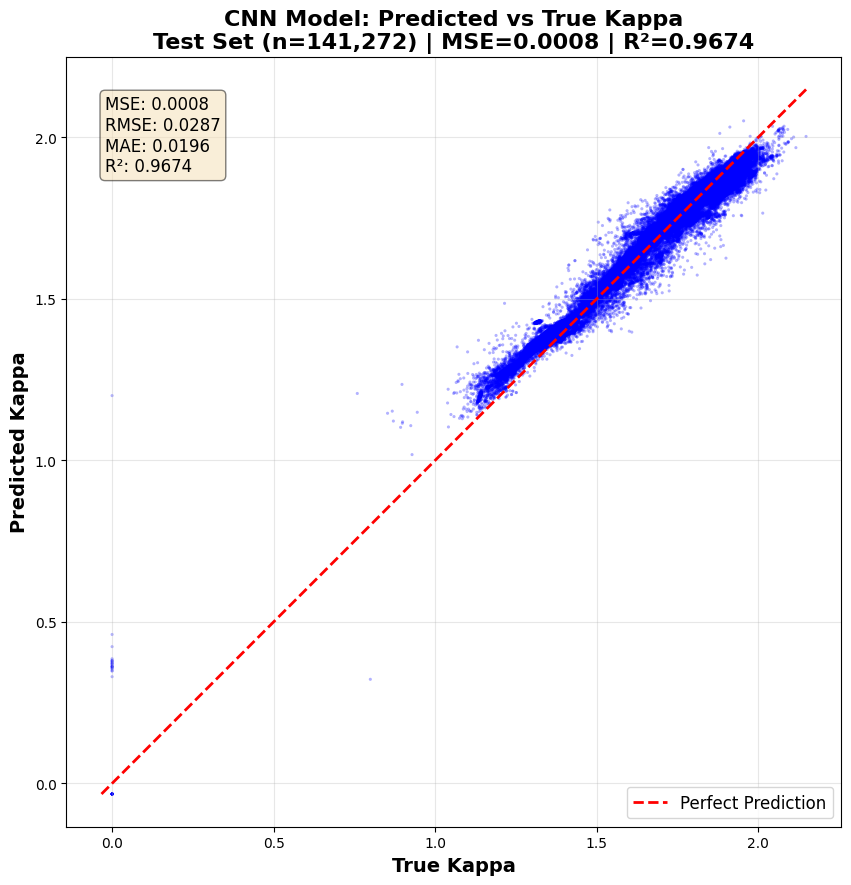

Scatter plot saved to test_predictions_scatter.png


In [20]:
# Scatter plot: Predicted vs True
plt.figure(figsize=(10, 10))
plt.scatter(all_targets, all_predictions, alpha=0.3, s=5, c='blue', edgecolors='none')

# Perfect prediction line
min_val = min(np.min(all_targets), np.min(all_predictions))
max_val = max(np.max(all_targets), np.max(all_predictions))
plt.plot([min_val, max_val], [min_val, max_val],
         'r--', lw=2, label='Perfect Prediction')

plt.xlabel('True Kappa', fontsize=14, fontweight='bold')
plt.ylabel('Predicted Kappa', fontsize=14, fontweight='bold')
plt.title(f'CNN Model: Predicted vs True Kappa\n'
          f'Test Set (n={len(all_targets):,}) | MSE={mse:.4f} | R²={r2:.4f}',
          fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.axis('equal')

# Add text box with metrics
textstr = f'MSE: {mse:.4f}\nRMSE: {rmse:.4f}\nMAE: {mae:.4f}\nR²: {r2:.4f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', bbox=props)

scatter_path = 'test_predictions_scatter.png'
plt.savefig(scatter_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Scatter plot saved to {scatter_path}")

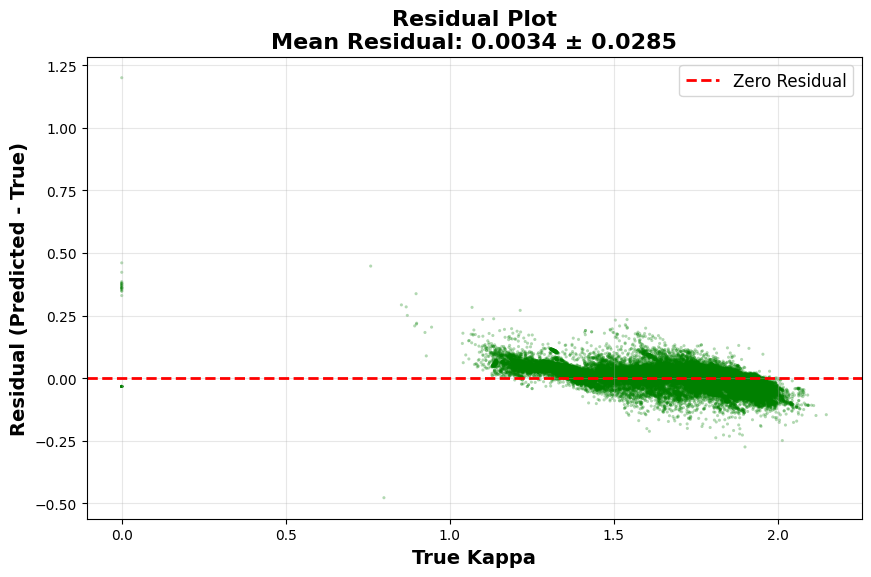

Residual plot saved to test_residuals.png


In [21]:
# Residual plot
residuals = all_predictions - all_targets

plt.figure(figsize=(10, 6))
plt.scatter(all_targets, residuals, alpha=0.3, s=5, c='green', edgecolors='none')
plt.axhline(y=0, color='r', linestyle='--', lw=2, label='Zero Residual')
plt.xlabel('True Kappa', fontsize=14, fontweight='bold')
plt.ylabel('Residual (Predicted - True)', fontsize=14, fontweight='bold')
plt.title(f'Residual Plot\nMean Residual: {np.mean(residuals):.4f} ± {np.std(residuals):.4f}',
          fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

residual_path = 'test_residuals.png'
plt.savefig(residual_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Residual plot saved to {residual_path}")

## Summary

This notebook demonstrated:
1. **Data Fetching**: Used `fdp python` via subprocess to fetch 2200 DIII-D shots with plasma shape data
2. **Model Training**: Trained a small CNN (42K parameters) to predict kappa from psirz flux distributions
3. **Evaluation**: Achieved excellent test performance (R² = 0.97, RMSE = 0.029)

### Key Results:
- Training samples: ~264K (80% of training set)
- Validation samples: ~66K (20% of training set)
- Test samples: ~141K
- Model converged in 5 epochs with no overfitting
- High prediction accuracy on unseen test data

### Files Created:
- `plasma_shape_train.nc` - Training data
- `plasma_shape_test.nc` - Test data
- `cnn_kappa_model.pth` - Trained model weights
- `normalization_params.npy` - Normalization parameters
- `loss_curves.png` - Training/validation loss curves
- `test_predictions_scatter.png` - Predicted vs true scatter plot
- `test_residuals.png` - Residual analysis plot